In [1]:
%load_ext autoreload
%autoreload 2
import numpy as np
import pyccl as ccl
import matplotlib.pyplot as plt
import pandas as pd
from scipy.interpolate import CubicSpline
from wale.CosmologyModel import *
from wale.CovarianceMatrix import *
from wale.InitializeVariables import *
from wale.VarianceCalculator import *
from wale.FilterFunctions import *
from wale.CommonUtils import *
from wale.CriticalPoints import *
from wale.ComputePDF import *
from wale.LoadSimulations import *

import cProfile, pstats


In [2]:
param_file = "/Users/vilasini/Documents/WALE/data/selected_params_halofit_unique.npy"
param_table = np.load(param_file)
param_table

from typing import Dict, Any

PARAM_NAMES = [r"$\Omega_{m}$", r"$\sigma_8$", r"$w_0$", r"$H_0$", r"$n_s$", r"$\Omega_b$"]

def load_cosmology_from_param_table(param_file: str, cosmo_index: int = 0) -> Dict[str, Any]:
    """
    Load cosmology parameters from a numpy file and return a dict of standard names.

    Supports:
    - numeric 2D arrays of shape (n_samples, 6)
    - numeric 1D arrays of length 6 (single sample)
    - structured numpy arrays with named fields (will attempt to map by PARAM_NAMES)

    Returned keys:
    - h, Oc (Omega_c), Ob (Omega_b), w (w0), wa, sigma8, Om, ns, H0
    """
    data = np.load(param_file, allow_pickle=True)

    # Structured dtype with names?
    if hasattr(data, "dtype") and data.dtype.names:
        # Try to map by latex labels or common equivalents
        def get_field(name_candidates):
            for nm in name_candidates:
                if nm in data.dtype.names:
                    return data[nm][cosmo_index] if data.ndim > 0 else data[nm].item()
            return None

        # common possible field names to check
        candidates = {
            "Omega_m": [r"$\\Omega_{m}$", "Omega_m", "Om", "omega_m", "omegam"],
            "sigma8": [r"$\\sigma_8$", "sigma8", "s8"],
            "w0": [r"$w_0$", "w0", "w"],
            "H0": [r"$H_0$", "H0", "h0"],
            "ns": [r"$n_s$", "ns"],
            "Omega_b": [r"$\\Omega_b$", "Omega_b", "Ob", "omegab"],
        }

        Omega_m = get_field(candidates["Omega_m"])
        sigma8 = get_field(candidates["sigma8"])
        w0 = get_field(candidates["w0"])
        H0 = get_field(candidates["H0"])
        ns = get_field(candidates["ns"])
        Omega_b = get_field(candidates["Omega_b"])

    else:
        # Numeric array: accept 1D length-6 or 2D samples x 6
        arr = np.asarray(data)
        if arr.ndim == 1 and arr.size == 6:
            row = arr
        elif arr.ndim == 2 and arr.shape[1] == 6:
            row = arr[cosmo_index]
        else:
            raise ValueError(f"Unexpected shape for param_table: {arr.shape}. Expect (6,) or (N,6).")

        Omega_m, sigma8, w0, H0, ns, Omega_b = row

    # Convert / compute standard quantities
    H0 = float(H0)
    h = H0 / 100.0
    Om = float(Omega_m)
    Ob = float(Omega_b)
    Oc = Om - Ob             # cold dark matter density
    w = float(w0)
    wa = 0.0                  # default unless present in table
    sigma8 = float(sigma8)
    ns = float(ns)

    return {
        "h": h,
        "Oc": Oc,
        "Ob": Ob,
        "w": w,
        "wa": wa,
        "sigma8": sigma8,
        "Om": Om,
        "ns": ns,
        "H0": H0,
    }

# Example usage:
# param_file = "/path/to/selected_params_halofit_unique.npy"
# params = load_cosmology_from_param_table(param_file, cosmo_index=5)
# h = params["h"]; Oc = params["Oc"]; Ob = params["Ob"]; ...

In [3]:
cosmogrid_kappa = np.load("../data/all_kappas_halofit_nobaryons_bin4.npy")
cosmogrid_l1norms = np.load("../data/all_l1_norms_halofit_nobaryons_bin4.npy")
cosmogrid_variances = np.load("../data/all_variances_halofit_nobaryons_bin4.npy")
cosmogrid_params = np.load("../data/selected_params_halofit.npy")

cosmogrid_snr = cosmogrid_kappa / (cosmogrid_variances[:, np.newaxis] ** 0.5)

print(cosmogrid_kappa.shape, cosmogrid_l1norms.shape, cosmogrid_variances.shape, cosmogrid_params.shape, cosmogrid_snr.shape)

id_zbin = 3  # Corresponds to the third redshift bin
nz_file = f"/Users/vilasini/Documents/WALE/data/nz/nz_stage3_{id_zbin+1}_GRID.txt"
print(f"Using n(z) file: {nz_file}")
theta1_input = 30.0  # Smoothing scale in arcmin
filter_type = 'tophat'

invalid_index = []
predictionl1 = []
predictionl1snr = []
cosmogrid=True

(1299, 500) (1299, 500) (1299,) (1299, 6) (1299, 500)
Using n(z) file: /Users/vilasini/Documents/WALE/data/nz/nz_stage3_4_GRID.txt


In [5]:
from joblib import Parallel, delayed

def process_one_cosmology(cosmoindex):
    print(f"\n--- Cosmology index: {cosmoindex} ---")

    # -------------------
    # Load cosmology params
    # -------------------
    if cosmogrid:
        Om      = cosmogrid_params[cosmoindex, 0]
        sigma8  = cosmogrid_params[cosmoindex, 1]
        w       = cosmogrid_params[cosmoindex, 2]
        h       = cosmogrid_params[cosmoindex, 3] / 100.
        ns      = cosmogrid_params[cosmoindex, 4]
        Ob      = cosmogrid_params[cosmoindex, 5]
        Oc      = Om - Ob
        wa      = 0.0
    else:
        params = load_cosmology_from_param_table(param_file, cosmo_index=cosmoindex)
        h      = params["h"]
        Ob     = params["Ob"]
        w      = params["w"]
        wa     = params["wa"]
        sigma8 = params["sigma8"]
        Om     = params["Om"]
        Oc     = Om - Ob
        ns     = params["ns"]

    theta1 = theta1_input

    # -------------------
    # (1) Initialise Variables
    # -------------------
    variables = InitialiseVariables(
        h=h, Oc=Oc, Ob=Ob, w=w, wa=wa, sigma8=sigma8,
        dk=0.005, kmin=1e-4, kmax=2.4,
        nz_file=nz_file, variability=False,
        theta1=theta1, nplanes=10, ns=ns
    )

    # -------------------
    # (2) Variance
    # -------------------
    variance = Variance(variables.cosmo, filter_type=filter_type, pk=variables.cosmo.pnl)
    variables.sigmasq_map = np.sum(
        variables.dchi * (variables.lensingweights ** 2) * np.array([
            variance.get_sig_slice(z, chi * variables.theta1_radian, chi * variables.theta2_radian)
            for z, chi in zip(variables.redshifts, variables.chis)
        ])
    )

    theory_sigmasq = compute_sigma_kappa_squared(
        theta1, variables.chis, variables.lensingweights,
        variables.redshifts, variables.cosmo.k, variables.cosmo.pnl,
        filter_type=filter_type, h=h
    )

    if cosmogrid:
        variance_cosmogrid = cosmogrid_variances[cosmoindex]
        variables.recal_value = variables.sigmasq_map / variance_cosmogrid
    else:
        variables.recal_value = variables.sigmasq_map / theory_sigmasq

    # -------------------
    # (3) Critical points
    # -------------------
    smallest_positive, largest_negative = find_critical_points_for_cosmo(
        variables, variance, ngrid_critical=25,
        plot=False, min_z=0, max_z=5
    )

    if smallest_positive and largest_negative is not None:
        variables.lambdas = np.linspace(largest_negative, smallest_positive, 20)

    # -------------------
    # (4) PDF / L1 prediction
    # -------------------
    if cosmogrid:
        kappa = cosmogrid_kappa[cosmoindex]
        computed_PDF = computePDF(variables, variance, plot_scgf=False, kappa=kappa)
    else:
        computed_PDF = computePDF(variables, variance, plot_scgf=False)

    pdf_vals    = computed_PDF.pdf_values
    kappa_vals  = computed_PDF.kappa_values
    norm_kappa  = kappa_vals / np.sqrt(theory_sigmasq)

    snr = cosmogrid_snr[cosmoindex]
    prediction_pdf = CubicSpline(norm_kappa, pdf_vals)(snr)
    prediction_l1  = CubicSpline(norm_kappa, np.abs(kappa_vals)*pdf_vals)(snr)

    pred_stats = get_moments(kappa_vals, pdf_vals)

    # -------------------
    # Return everything needed for plotting
    # -------------------
    return {
        "index": cosmoindex,
        "valid": (np.abs(pred_stats[0]) < 1e-6),
        "kappa_vals": kappa_vals,
        "pdf_vals": pdf_vals,
        "snr": snr,
        "prediction_l1_snr": prediction_l1,
        "theory_l1_kappa": np.abs(kappa_vals) * pdf_vals,
        "pred_stats": pred_stats
    }


In [8]:
len(cosmogrid_params)

1299

In [ ]:
results = Parallel(n_jobs=6, verbose=10)(
    delayed(process_one_cosmology)(i) 
    for i in range(len(cosmogrid_params))
)

[Parallel(n_jobs=6)]: Using backend LokyBackend with 6 concurrent workers.



--- Cosmology index: 0 ---
   Using scalar spectral index ns = 1.0075

--- Cosmology index: 1 ---
   Using scalar spectral index ns = 1.0075

Initialised Cosmology:
  h = 0.78625, Oc = 0.289375, Ob = 0.035625, w = -1.0623125, wa = 0.0, sigma8 = 0.8375
  k-range: [0.0001, 2.4] with step dk = 0.005

Initialising WALE with the following parameters:
   Initialised Variables:
      Source redshift: from nz file
      Number of planes: 10
      Angular scale theta1 (radians): 0.008726646259971648, arcmin: 30.0

Initialised Cosmology:
  h = 0.78625, Oc = 0.289375, Ob = 0.035625, w = -1.0623125, wa = 0.0, sigma8 = 0.8375
  k-range: [0.0001, 2.4] with step dk = 0.005

Initialising WALE with the following parameters:
   Initialised Variables:
      Source redshift: from nz file
      Number of planes: 10
      Angular scale theta1 (radians): 0.008726646259971648, arcmin: 30.0

--- Cosmology index: 2 ---
   Using scalar spectral index ns = 1.0075

Initialised Cosmology:
  h = 0.78625, Oc = 0.289

/var/folders/4z/j812r6_x1b33_hsc69yh9m240000gp/T/ipykernel_96531/3955344949.py:18: RuntimeWarning: divide by zero encountered in divide
  residual = (pred_l1_snr - cosmogrid_l1norms[r["index"]]) / cosmogrid_l1norms[r["index"]]
/var/folders/4z/j812r6_x1b33_hsc69yh9m240000gp/T/ipykernel_96531/3955344949.py:24: RuntimeWarning: divide by zero encountered in divide
  residual_l1 = (pred_l1_kappa - cosmogrid_l1norms[r["index"]]) / cosmogrid_l1norms[r["index"]]


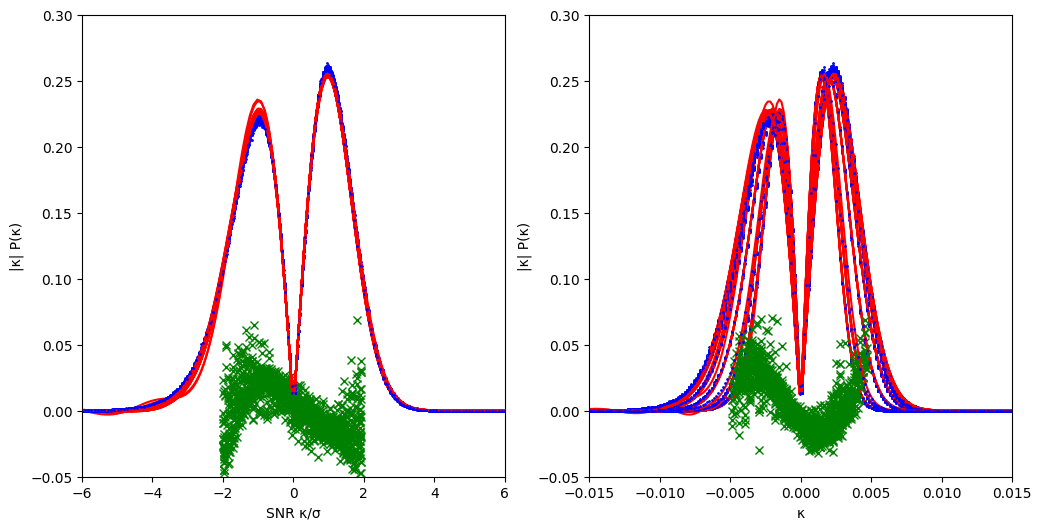

In [7]:
valid_results = [r for r in results if r["valid"]]
invalid_indices = [r["index"] for r in results if not r["valid"]]

fig, ax = plt.subplots(1, 2, figsize=(12, 6))

for r in valid_results:
    kappa_vals = r["kappa_vals"]
    # pdf_vals   = r["pdf_vals"]
    snr        = r["snr"]
    pred_l1_snr    = r["prediction_l1_snr"]
    pred_l1_kappa = r["theory_l1_kappa"]

    pred_stats = r["pred_stats"]
    sigma = np.sqrt(pred_stats[1])
    
    ax[0].plot(snr, pred_l1_snr, 'r')
    ax[0].plot(cosmogrid_snr[r["index"]], cosmogrid_l1norms[r["index"]], 'o', ms=1, color='blue')
    residual = (pred_l1_snr - cosmogrid_l1norms[r["index"]]) / cosmogrid_l1norms[r["index"]]
    mask = np.where((snr>-2)&(snr<2))
    ax[0].plot(snr[mask][::2], residual[mask][::2], 'x', color='green')

    ax[1].plot(kappa_vals, pred_l1_kappa, 'r')
    ax[1].plot(kappa_vals, cosmogrid_l1norms[r["index"]], 'o', ms=1, color='blue')
    residual_l1 = (pred_l1_kappa - cosmogrid_l1norms[r["index"]]) / cosmogrid_l1norms[r["index"]]
    mask_l1 = np.where((kappa_vals>-2*sigma)&(kappa_vals<2*sigma))
    ax[1].plot(kappa_vals[mask_l1][::2], residual_l1[mask_l1][::2], 'x', color='green')

ax[0].set_xlabel("SNR κ/σ")
ax[0].set_ylabel("|κ| P(κ)")
ax[0].set_xlim(-6, 6)
ax[0].set_ylim(-0.05, 0.3)

ax[1].set_xlabel("κ")
ax[1].set_ylabel("|κ| P(κ)")
ax[1].set_xlim(-0.015, 0.015)
ax[1].set_ylim(-0.05, 0.3)
plt.show()
